<a href="https://colab.research.google.com/github/ayeshayaz/python-practice/blob/main/powercut_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

            timestamp  hour  weekday  power_cut
0 2026-05-17 00:00:00     0        6          0
1 2026-05-17 01:00:00     1        6          0
2 2026-05-17 02:00:00     2        6          0
3 2026-05-17 03:00:00     3        6          0
4 2026-05-17 04:00:00     4        6          0

Total hours logged: 1440, hours with cuts: 233


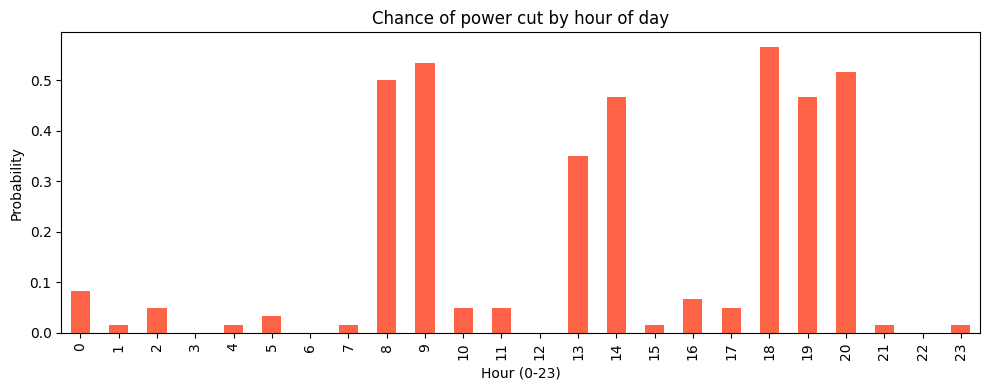

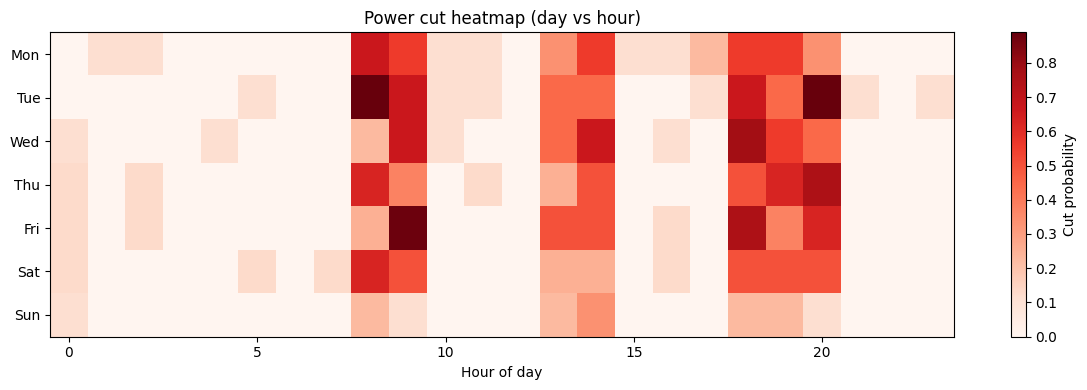

              precision    recall  f1-score   support

           0       0.91      0.90      0.90       245
           1       0.45      0.47      0.46        43

    accuracy                           0.84       288
   macro avg       0.68      0.68      0.68       288
weighted avg       0.84      0.84      0.84       288

Wed at 19:00 -> chance of power cut in the next hour: 96%
  >> WARNING: save your work / checkpoint now!
Sun at 3:00 -> chance of power cut in the next hour: 0%


np.float64(0.0)

In [1]:
# ============================================================
# PROJECT 1 — POWER CUT (LOAD SHEDDING) PREDICTOR
# RUN THIS IN GOOGLE COLAB
#
# What it does:
#   1. Creates a realistic sample power-cut log (later you will
#      replace this with YOUR real log from your laptop).
#   2. Learns the pattern: which hours / days cuts happen.
#   3. Trains an ML model to predict: "will there be a cut
#      in the next hour?"
#   4. Shows charts + gives a prediction for any time you ask.
#
# How to use in Colab:
#   - Paste each SECTION into its own cell, or paste the whole
#     file into one cell. Then run.
# ============================================================

# ---------- SECTION 1: setup ----------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

np.random.seed(42)

# ---------- SECTION 2: make sample outage data ----------
# We simulate 60 days of load shedding for a Lahore-like schedule:
#   - Likely cuts around 8-9 AM, 1-2 PM, 6-8 PM
#   - Worse on hot weekdays, lighter on Sunday
# LATER: replace this whole section with:
#   df = pd.read_csv("power_log.csv")   # the file from your laptop

def simulate_outages(days=60):
    rows = []
    start = datetime.now() - timedelta(days=days)
    for d in range(days):
        day = start + timedelta(days=d)
        weekday = day.weekday()          # 0=Mon ... 6=Sun
        for hour in range(24):
            # base chance of a cut this hour
            p = 0.03
            if hour in (8, 9):    p = 0.55
            if hour in (13, 14):  p = 0.45
            if hour in (18, 19, 20): p = 0.60
            if weekday == 6:      p *= 0.5   # Sunday lighter
            cut = np.random.rand() < p
            rows.append({
                "timestamp": day.replace(hour=hour, minute=0, second=0, microsecond=0),
                "hour": hour,
                "weekday": weekday,
                "power_cut": int(cut),
            })
    return pd.DataFrame(rows)

df = simulate_outages()
print(df.head())
print(f"\nTotal hours logged: {len(df)}, hours with cuts: {df.power_cut.sum()}")

# ---------- SECTION 3: see the pattern ----------
pattern = df.groupby("hour")["power_cut"].mean()

plt.figure(figsize=(10, 4))
pattern.plot(kind="bar", color="tomato")
plt.title("Chance of power cut by hour of day")
plt.xlabel("Hour (0-23)")
plt.ylabel("Probability")
plt.tight_layout()
plt.show()

heat = df.pivot_table(index="weekday", columns="hour",
                      values="power_cut", aggfunc="mean")
plt.figure(figsize=(12, 4))
plt.imshow(heat, aspect="auto", cmap="Reds")
plt.colorbar(label="Cut probability")
plt.yticks(range(7), ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
plt.xlabel("Hour of day")
plt.title("Power cut heatmap (day vs hour)")
plt.tight_layout()
plt.show()

# ---------- SECTION 4: train a predictor ----------
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Features: hour, weekday, and "was there a cut in the previous
# 1 and 2 hours" (cuts often follow a schedule pattern)
df = df.sort_values("timestamp").reset_index(drop=True)
df["cut_prev_1h"] = df["power_cut"].shift(1).fillna(0)
df["cut_prev_2h"] = df["power_cut"].shift(2).fillna(0)

X = df[["hour", "weekday", "cut_prev_1h", "cut_prev_2h"]]
y = df["power_cut"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False)   # keep time order

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

print(classification_report(y_test, model.predict(X_test)))

# ---------- SECTION 5: ask the model ----------
def predict_cut(hour, weekday, cut_1h_ago=0, cut_2h_ago=0):
    """weekday: 0=Mon ... 6=Sun"""
    p = model.predict_proba(
        pd.DataFrame([{
            "hour": hour, "weekday": weekday,
            "cut_prev_1h": cut_1h_ago, "cut_prev_2h": cut_2h_ago
        }])
    )[0][1]
    names = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
    print(f"{names[weekday]} at {hour}:00 -> "
          f"chance of power cut in the next hour: {p*100:.0f}%")
    if p > 0.5:
        print("  >> WARNING: save your work / checkpoint now!")
    return p

# Examples:
predict_cut(hour=19, weekday=2)   # Wednesday 7 PM
predict_cut(hour=3,  weekday=6)   # Sunday 3 AM

# ---------- NEXT STEPS (your real project) ----------
# 1. Run the laptop script (power_logger_LAPTOP.py) on your Mac
#    for 2-4 weeks. It creates power_log.csv from REAL cuts.
# 2. Replace Section 2 with: df = pd.read_csv("power_log.csv")
# 3. Retrain. Now the model knows YOUR area's real schedule.
# 4. Advanced: make the laptop script ask the model every 10 min,
#    and auto-save / checkpoint jobs when risk > 50%.